In [1]:
import model_template as model
import pandas as pd
import numpy as np
import pollux as plx
from pollux.models.transforms import LinearTransform
import matplotlib.pyplot as plt
from matplotlib import rcParams
import time

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [2]:
results_n_latents = pd.read_csv("latent_scan_results_dwarfs.csv")
results_n_latents.head()

,n_latent,delta_t,rmse,rmse_teff,rmse_logg,rmse_fe_h,rmse_mg_h,rmse_si_h,rmse_ni_h,rmse_ca_h
0,12,40.664225,49.148041,130.033109,0.175655,0.094712,0.094025,0.093258,0.154132,0.137907
1,13,44.417753,49.095364,129.893738,0.174849,0.094301,0.092877,0.093262,0.157082,0.135828
2,14,40.350169,50.553922,133.752738,0.171191,0.094996,0.090945,0.092230,0.156177,0.136822
3,15,39.672841,52.162821,138.009496,0.170075,0.096029,0.089383,0.092210,0.157586,0.136157
4,16,45.868332,51.278558,135.669948,0.169904,0.097591,0.090710,0.093762,0.157699,0.135924


In [11]:
# Columns to include in global metric
rmse_cols = [
    'rmse_teff',
    'rmse_logg',
    'rmse_fe_h',
    'rmse_mg_h',
    'rmse_si_h',
    'rmse_ni_h',
    'rmse_ca_h'
]

# --- Normalize by column mean ---
norm_factors = results_n_latents[rmse_cols].mean()

normalized = results_n_latents[rmse_cols] / norm_factors

# --- Aggregate (RMS across labels) ---
results_n_latents['rmse_global_norm'] = np.sqrt(
    (normalized ** 2).mean(axis=1)
)

# --- Sort and inspect ---
results_sorted = results_n_latents.sort_values('rmse_global_norm')

best1 = results_sorted.iloc[0]
best3 = results_sorted.head(3)

print("Best configuration:")
print(best1[['n_latent','rmse_global_norm']])
print("\nTop 3:")
print(best3[['n_latent','rmse_global_norm']])

Best configuration:
n_latent            17.000000
rmse_global_norm     0.985339
Name: 5, dtype: float64

Top 3:
   n_latent  rmse_global_norm
5        17          0.985339
9        21          0.986588
2        14          0.988274


In [3]:
min_idx = results_n_latents['rmse'].idxmin()
best_n_latent = results_n_latents.loc[min_idx]

print(best_n_latent)

n_latent      13.000000
delta_t       44.417753
rmse          49.095364
rmse_teff    129.893738
rmse_logg      0.174849
rmse_fe_h      0.094301
rmse_mg_h      0.092877
rmse_si_h      0.093262
rmse_ni_h      0.157082
rmse_ca_h      0.135828
Name: 1, dtype: float64


In [4]:
best3 = results_n_latents.nsmallest(3, 'rmse')

best3

,n_latent,delta_t,rmse,rmse_teff,rmse_logg,rmse_fe_h,rmse_mg_h,rmse_si_h,rmse_ni_h,rmse_ca_h
1,13,44.417753,49.095364,129.893738,0.174849,0.094301,0.092877,0.093262,0.157082,0.135828
0,12,40.664225,49.148041,130.033109,0.175655,0.094712,0.094025,0.093258,0.154132,0.137907
2,14,40.350169,50.553922,133.752738,0.171191,0.094996,0.090945,0.092230,0.156177,0.136822


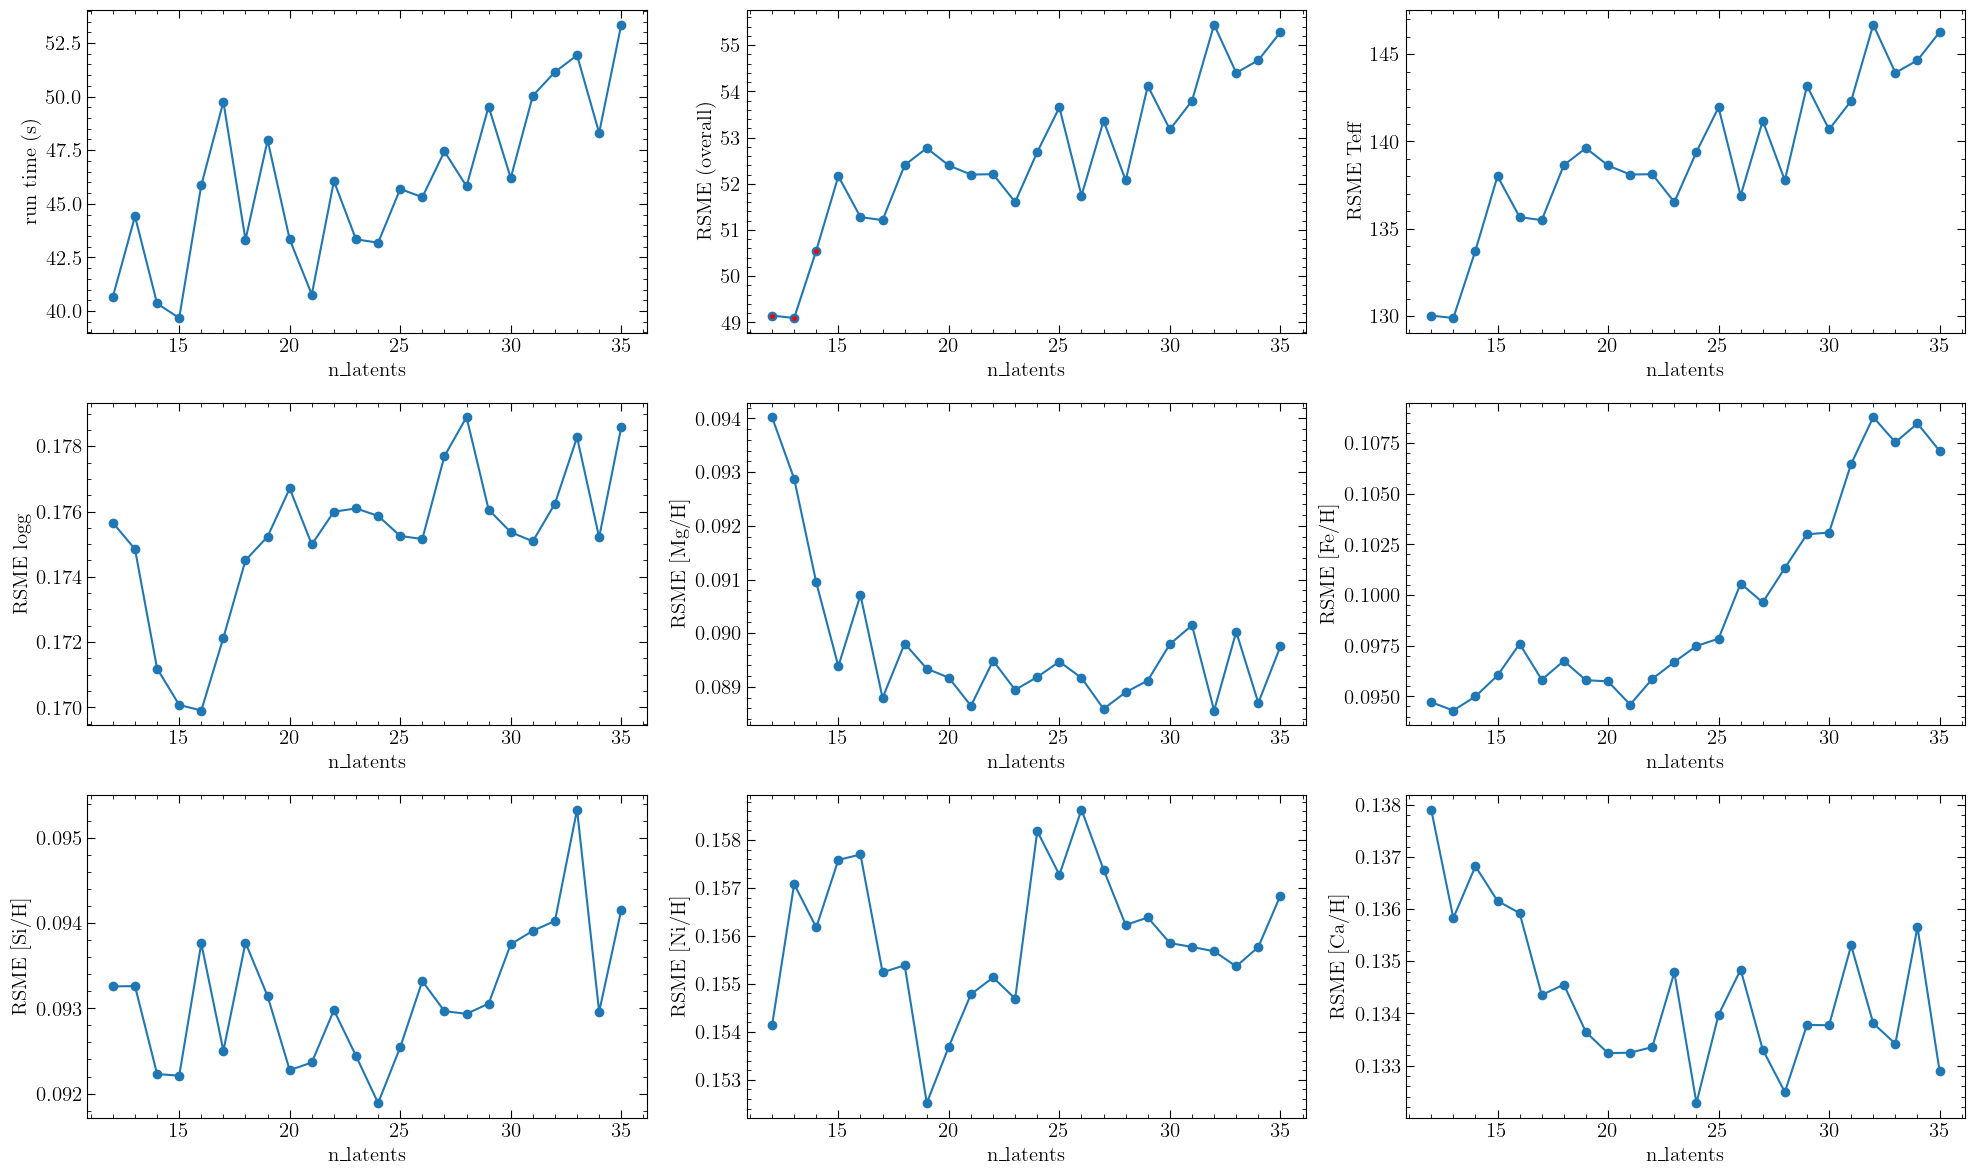

In [9]:
n_rows = 3
n_cols = 3
plt.figure(figsize=(20,12))

plt.subplot(3,n_cols,1)
plt.plot(results_n_latents['n_latent'], results_n_latents['delta_t'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("run time (s)")

plt.subplot(3,n_cols,2)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME (overall)")
plt.scatter(best3['n_latent'], best3['rmse'], marker='*', s=10, color = 'red', zorder=5)

plt.subplot(3,n_cols,3)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_teff'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME Teff")

plt.subplot(3,n_cols,4)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_logg'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME logg")

plt.subplot(3,n_cols,5)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_mg_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Mg/H]")

plt.subplot(3,n_cols,6)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_fe_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Fe/H]")

plt.subplot(3,n_cols,7)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_si_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Si/H]")

plt.subplot(3,n_cols,8)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ni_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Ni/H]")

plt.subplot(3,n_cols,9)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ca_h'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME [Ca/H]")


plt.tight_layout()

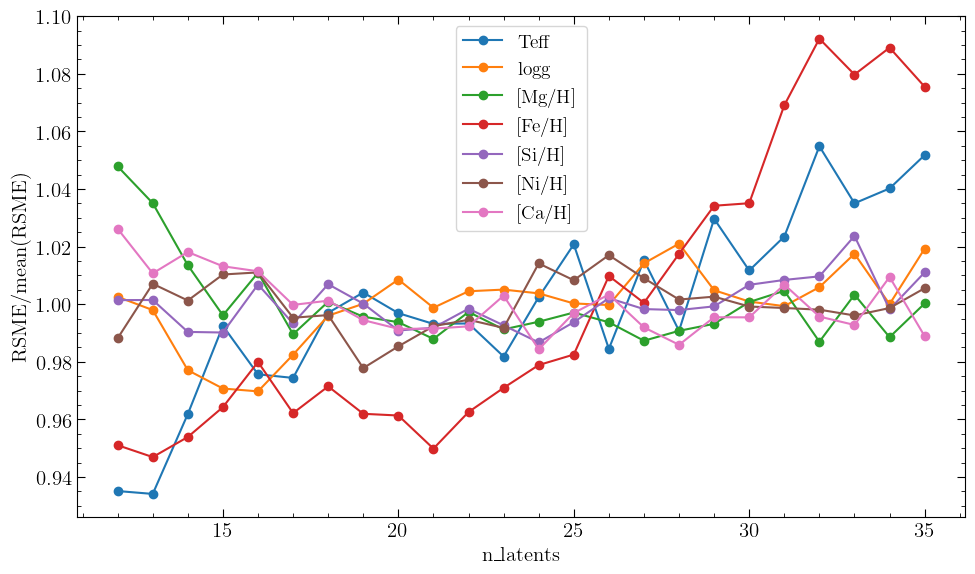

In [7]:
plt.figure(figsize=(10,6))


plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_teff']/np.mean(results_n_latents['rmse_teff']), marker='o', label = 'Teff')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_logg']/np.mean(results_n_latents['rmse_logg']), marker='o', label = 'logg')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_mg_h']/np.mean(results_n_latents['rmse_mg_h']), marker='o', label = '[Mg/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_fe_h']/np.mean(results_n_latents['rmse_fe_h']), marker='o', label = '[Fe/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_si_h']/np.mean(results_n_latents['rmse_si_h']), marker='o', label = '[Si/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ni_h']/np.mean(results_n_latents['rmse_ni_h']), marker='o', label = '[Ni/H]')
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse_ca_h']/np.mean(results_n_latents['rmse_ca_h']), marker='o', label = '[Ca/H]')
plt.legend()

plt.xlabel("n_latents")
plt.ylabel("RSME/mean(RSME)")
plt.tight_layout()

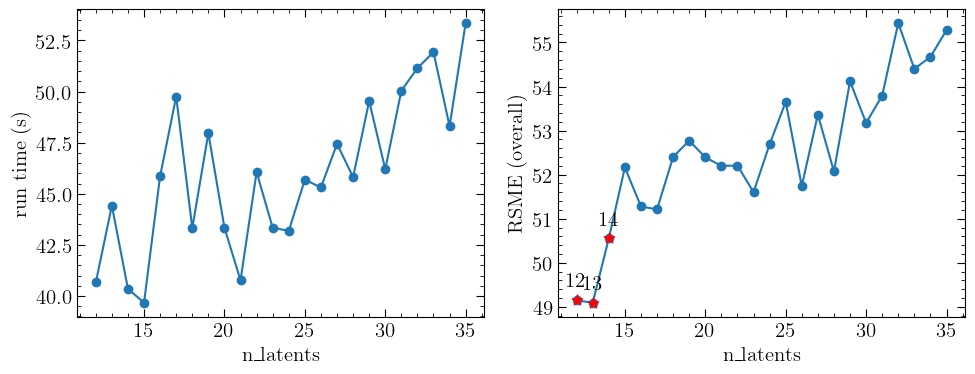

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(results_n_latents['n_latent'], results_n_latents['delta_t'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("run time (s)")

plt.subplot(1,2,2)
plt.plot(results_n_latents['n_latent'], results_n_latents['rmse'], marker='o')
plt.xlabel("n_latents")
plt.ylabel("RSME (overall)")
plt.scatter(best3['n_latent'], best3['rmse'], marker='*', s=60, color = 'red', zorder=5)
for _, row in best3.iterrows():
    plt.annotate(
        text=f"{int(row['n_latent'])}",
        xy=(row['n_latent'], row['rmse']),
        xytext=(0, 10),                 # offset text slightly above
        textcoords="offset points",
        ha='center'
    )

plt.tight_layout()

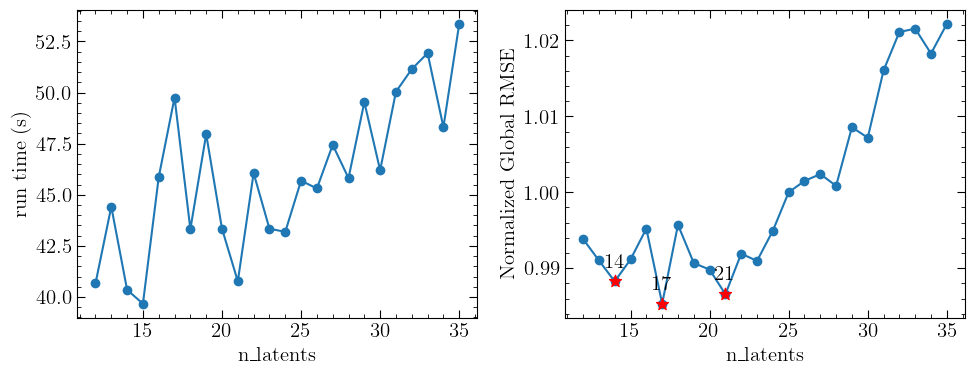

In [12]:
plt.figure(figsize=(10,4))

# --- Runtime ---
plt.subplot(1,2,1)
plt.plot(results_n_latents['n_latent'],
         results_n_latents['delta_t'],
         marker='o')
plt.xlabel("n_latents")
plt.ylabel("run time (s)")

# --- Normalized Global RMSE ---
plt.subplot(1,2,2)
plt.plot(results_n_latents['n_latent'],
         results_n_latents['rmse_global_norm'],
         marker='o')

plt.xlabel("n_latents")
plt.ylabel("Normalized Global RMSE")

# highlight best 3
plt.scatter(best3['n_latent'],
            best3['rmse_global_norm'],
            marker='*',
            s=80,
            color='red',
            zorder=5)

for _, row in best3.iterrows():
    plt.annotate(
        text=f"{int(row['n_latent'])}",
        xy=(row['n_latent'], row['rmse_global_norm']),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center'
    )

plt.tight_layout()
